In [3]:
# %%
import json
import os
import re
import time
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, mean_squared_error
from sentence_transformers import SentenceTransformer, util
from concurrent.futures import ThreadPoolExecutor, as_completed
from dotenv import load_dotenv

load_dotenv()

# Load the semantic embedder once
print("Loading semantic embedder...")
embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

INPUT_FILE = "true_test_split.jsonl"
OUTPUT_FILE = "benchmark_results_all_models.jsonl"

# Ideology Classes
IDEOLOGY_CLASSES = [
    "Far-Left", "Left", "Center-Left", "Center / Neutral", 
    "Center-Right", "Right", "Far-Right"
]

def get_ideology_class(score):
    try:
        val = float(score)
        if val <= 0.15: return "Far-Left"
        elif val <= 0.35: return "Left"
        elif val <= 0.45: return "Center-Left"
        elif val <= 0.55: return "Center / Neutral"
        elif val <= 0.65: return "Center-Right"
        elif val <= 0.85: return "Right"
        else: return "Far-Right"
    except (ValueError, TypeError):
        return None

/Users/koules/Developer/side_projects/keifer_hackathon/prep/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading semantic embedder...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10330.16it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# %%
# ──────────────────────────────────────────────
# CONFIGURATION
# ──────────────────────────────────────────────
# vLLM Configuration (from env variables)
VLLM_URL = f"http://{os.environ.get('VLLM_HOST', '10.184.94.22')}:{os.environ.get('VLLM_PORT', '30070')}/v1/chat/completions"
VLLM_API_KEY = os.environ.get("VLLM_API_KEY", "my-secret-key")
VLLM_MODEL = os.environ.get("VLLM_MODEL", "/bigono/work/true_fused_qwen_moe")

# Base Qwen Configuration (Update these to match where your base model is hosted)
BASE_QWEN_URL = f"http://{os.environ.get('BASE_VLLM_HOST', '10.184.94.22')}:{os.environ.get('BASE_VLLM_PORT', '30071')}/v1/chat/completions"
BASE_QWEN_API_KEY = os.environ.get("BASE_VLLM_API_KEY", "my-secret-key")
BASE_QWEN_MODEL = os.environ.get("BASE_VLLM_MODEL", "/bigono/qwen")

TIMEOUT = 120
TEMPERATURE = 0.1
MAX_TOKENS = 20000

SYSTEM_PROMPT = """
You are an expert Political Data Scientist and Computational Linguist specializing in Greek digital media and political discourse. Your task is to perform a deep-structure ideological analysis of Greek news articles.

TASK:
1. Analyze the provided Greek news article for political bias, framing, and ideological stance.
2. Provide a concise reasoning in Greek (2-4 sentences) justifying the analysis.
3. Extract 1-3 primary political entities (politicians, parties, institutions) targeted or discussed in the text.
4. Assign a precise ideological leaning score on a continuous scale from 0.0 to 1.0.

IDEOLOGICAL ANCHORS (Left vs Right & Populism vs Institutionalism):
- 0.00 - 0.15: Far-Left (Radical systemic critique, anti-capitalist, anti-establishment/populist framing)
- 0.16 - 0.35: Left (Socialist/Progressive focus, labor rights, strong state intervention)
- 0.36 - 0.45: Center-Left (Social democratic leaning, moderate reformism, pro-EU)
- 0.46 - 0.55: Center / Neutral (Strictly objective reporting, institutionalist, multi-perspective balance)
- 0.56 - 0.65: Center-Right (Liberal-conservative, market-oriented, institutionalist/pro-EU)
- 0.66 - 0.85: Right (Conservative, national focus, law and order, pro-business)
- 0.86 - 1.00: Far-Right (Ultra-nationalist, nativist framing, reactionary/anti-systemic rhetoric)

REASONING GUIDELINES (Greek):
Your reasoning must identify:
- Lexical choices (e.g., use of "λαϊκισμός", "δικαιωματισμός", "καθεστώς", "ελίτ").
- Framing of political actors (who is portrayed as the protagonist/antagonist?).
- Source selection (whose views are prioritized or omitted?).

STRICT OUTPUT FORMAT:
Return ONLY a valid JSON object. Do not include markdown code blocks, headers, or any text before/after the JSON. 

JSON SCHEMA:
{
  "reasoning": "string (in Greek, 2-4 sentences)",
  "primary_entities": ["string", "string"],
  "bias": float (0.00 to 1.00)
}

FEW-SHOT EXAMPLES:

=== EXAMPLE 1 ===
User:
Τίτλος: Θεσσαλονίκη: Χειροπέδες σε 25χρονο Τούρκο που είχε καταδικαστεί για ναρκωτικά στην πατρίδα του

Άρθρο:
Θεσσαλονίκη Τουρκία Δικαστήριο Καταδικασμένος από τουρκικό δικαστήριο για κατοχή και διακίνηση ναρκωτικών συνελήφθη στη Θεσσαλονίκη , σε εκτέλεση διεθνούς εντάλματος των διωκτικών αρχών της γειτονικής χώρας. Πρόκειται για 25χρονο, Τούρκο υπήκοο, στον οποίο αστυνομικοί του Τμήματος Αναζητήσεων της Διεύθυνσης Δίωξης και Εξιχνίασης Εγκλημάτων Θεσσαλονίκης πέρασαν χθες το πρωί χειροπέδες. Σύμφωνα με τα διωκτικά έγγραφα, οι τουρκικές αρχές ζητούν την έκδοσή του για να εκτίσει το υπόλοιπο της ποινής της 8ετούς κάθειρξης (και επιπλέον 4 μηνών) που του είχε επιβληθεί. Η πράξη για την οποία τιμωρήθηκε φέρεται να τελέστηκε τον Φεβρουάριο του 2021, στην Κωνσταντινούπολη. Ο εκζητούμενος οδηγείται στην Εισαγγελία Εφετών Θεσσαλονίκης για να δρομολογηθούν οι διαδικασίες αναφορικά με το τουρκικό αίτημα.

Assistant:
{"reasoning": "Το άρθρο παρουσιάζει ένα γεγονός (σύλληψη και διαδικασία έκδοσης) με καθαρά περιγραφικό και ουδέτερο τρόπο. Δεν χρησιμοποιεί φορτισμένη γλώσσα, δεν εκφράζει γνώμη ή συναισθηματική φόρτιση και εστιάζει αποκλειστικά στα νομικά και διαδικαστικά στοιχεία, χωρίς πολιτικό σχολιασμό.", "primary_entities": ["25χρονος Τούρκος", "Τουρκικές αρχές", "Εισαγγελία Εφετών Θεσσαλονίκης"], "bias": 0.5}

=== EXAMPLE 2 ===
User:
Τίτλος: Ελεύθερος αφέθηκε λύκος που επιτέθηκε σε γυναίκα στο Αμβούργο, του έβαλαν πομπό εντοπισμού

Άρθρο:
Λύκος Γερμανία Επίθεση Ένας λύκος που αιχμαλωτίστηκε μετά την επίθεσή του την προηγούμενη εβδομάδα σε γυναίκα σε προάστιο του Αμβούργου στη Γερμανία , αφέθηκε ελεύθερος σε δάσος αφού πρώτα του τοποθετήθηκε πομπός εντοπισμού, όπως ανακοίνωσαν οι αρχές της γερμανικής πόλης. Ο νεαρός αρσενικός λύκος αφέθηκε ελεύθερος την Κυριακή σε τοποθεσία που δεν αποκαλύφθηκε . « Βρήκαμε μια νομικά ασφαλή λύση με την επανένταξη αυτού του λύκου στο φυσικό του περιβάλλον, λαμβάνοντας υπόψη την ασφάλεια των κατοίκων και την ευημερία του ζώου », δήλωσε η αντιδήμαρχος Περιβάλλοντος Καταρίνα Φέγκεμπανκ. Χάρη στη συσκευή που τοποθετήθηκε στο ζώο, σε περίπτωση που ο λύκος προσεγγίσει ξανά κατοικημένη περιοχή, οι αρχές θα μπορούσαν να παρέμβουν και να τον εντοπίσουν γρήγορα. Ο λύκος εθεάθη σε προάστιο του Αμβούργου στα τέλη Μαρτίου. Το βράδυ της 30ής Μαρτίου μπήκε σε εμπορικό κέντρο της Αλτόνα και επιτέθηκε σε μια γυναίκα, ηλικίας περίπου 60 ετών . Συνεργεία τον εντόπισαν αργότερα στη λίμνη Μπινενάλστερ, όπου τον αιχμαλώτισαν. Σύμφωνα με τις τοπικές αρχές, ο λύκος φέρεται να δάγκωσε τη γυναίκα την ώρα που εκείνη προσπαθούσε να ανοίξει την αυτόματη γυάλινη πόρτα ώστε να βγει έξω το άγριο ζώο . Υπάρχει επίσης μια μαρτυρία που αναφέρει ότι ο λύκος όρμησε πάνω στη γυναίκα, αλλά δεν τη δάγκωσε . Χθες Κυριακή, σχεδόν 100 διαδηλωτές συγκεντρώθηκαν έξω από το κέντρο όπου παρέμενε αιχμάλωτος ο λύκος , προκειμένου να πιέσουν τις αρχές να τον αφήσουν ελεύθερο στο φυσικό του περιβάλλον.

Assistant:
{"reasoning": "Το άρθρο παρουσιάζει με ουδέτερο τρόπο ένα περιστατικό με λύκο στο Αμβούργο. Εστιάζει στην απόφαση των αρχών και την αιτιολόγησή της ως «νομικά ασφαλή λύση», υπογραμμίζοντας τον θεσμικό χειρισμό του ζητήματος. Δεν χρησιμοποιεί φορτισμένη γλώσσα ούτε παίρνει θέση υπέρ ή κατά κάποιας πλευράς.", "primary_entities": ["Αρχές Αμβούργου", "Λύκος"], "bias": 0.52}

=== EXAMPLE 3 ===
User:
Τίτλος: H LAMDA επενδύει στις τοπικές κοινωνίες με νέες πρωτοβουλίες σε συνεργασία με κορυφαία επιστημονικά ιδρύματα και φορείς

Άρθρο:
Ένα νέο, ουσιαστικό κεφάλαιο συνεργασίας με τις τοπικές κοινωνίες, ανοίγει η LAMDA Development, παρουσιάζοντας νέες πρωτοβουλίες για την προστασία του περιβάλλοντος, την αντιμετώπιση της κλιματικής κρίσης, και την ενίσχυση ευπαθών κοινωνικών ομάδων σε συνεργασία με κορυφαία πανεπιστημιακά ιδρύματα και επιστημονικούς φορείς της χώρας. Οι πρωτοβουλίες της LAMDA, οι οποίες παρουσιάστηκαν σε εκδήλωση στο Μουσείο Κυκλαδικής Τέχνης, έχουν στον πυρήνα τους τη βελτίωση της ποιότητας ζωής των κατοίκων των όμορων περιοχών και τη θωράκιση από τις επιπτώσεις της κλιματικής αλλαγής. Αφετηρία αποτέλεσαν οι ανάγκες, οι προσδοκίες αλλά και οι ανησυχίες των κατοίκων των όμορων Δήμων, όπως καταγράφηκαν μέσα από εκτεταμένες έρευνες που πραγματοποίησε η LAMDA στο πλαίσιο της ανάπτυξης του The Ellinikon. Παράλληλα, οι έρευνες ανέδειξαν και τις προκλήσεις που συνδέονται με την κατασκευαστική δραστηριότητα ενός τόσο μεγάλου έργου. Με βάση τα ευρήματα αυτά, η LAMDA σχεδίασε ένα συνεκτικό πλέγμα δράσεων που εστιάζει: - στην προστασία και ενίσχυση του φυσικού περιβάλλοντος, - στην αντιμετώπιση της κλιματικής αλλαγής, - στη στήριξη των ευπαθών ομάδων και της νέας γενιάς, - καθώς και στον περιορισμό της όχλησης και του περιβαλλοντικού αποτυπώματος από τις κατασκευαστικές εργασίες. Επίσης, δημιουργείται ένας ειδικός διαδραστικός πίνακας (dashboard) στην ιστοσελίδα του The Ellinikon για on-line παρακολούθηση των μετρήσεων από κάθε ενδιαφερόμενο μέρος με στόχο την πλήρη διαφάνεια. Κλείσιμο Με ξεκάθαρο στόχο, οι δράσεις αυτές να παράγουν μετρήσιμα, διαχρονικά και ουσιαστικά αποτελέσματα, η LAMDA προχώρησε σε στρατηγικές συνεργασίες με το Γεωπονικό Πανεπιστήμιο Αθηνών, το Εθνικό Αστεροσκοπείο Αθηνών, το Ελληνικό Κέντρο Θαλασσίων Ερευνών (ΕΛ.ΚΕ.Θ.Ε.) και άλλους διακεκριμένους φορείς της χώρας. Παρουσιάζοντας τις νέες πρωτοβουλίες, η Σίσσυ Ηλιοπούλου, Chief Marketing & Communication Officer της LAMDA, υπογράμμισε: «Βασικός μας στόχος είναι ο διαρκής, ανοιχτός, ειλικρινής και – πάνω απ’ όλα – εποικοδομητικός διάλογος με τους γείτονές μας και όλους τους εταίρους μας. Το έργο του Ελληνικού δεν είναι απλώς μια μεγάλη ανάπτυξη. Είναι μια μοναδική ευκαιρία για Αθήνα και την Ελλάδα, με θετικό αποτύπωμα στην κοινωνία και το περιβάλλον». H Καθηγήτρια, Διευθύντρια Ανθοκομίας και Αρχιτεκτονικής Τοπίου του Γεωπονικού Πανεπιστημίου Αθηνών, Δρ. Μαρία Παπαφωτίου ανέφερε: «Η συνεργασία του Γεωπονικού Πανεπιστημίου Αθηνών με τη LAMDA αποτελεί ένα ουσιαστικό βήμα σύνδεσης της επιστημονικής γνώσης με την πράξη. Η μελέτη που παρουσιάσαμε τεκμηριώνει πώς ο αστικός σχεδιασμός μπορεί να ενισχύσει το πράσινο και τη βιοποικιλότητα, να βελτιώσει το μικροκλίμα και να αναβαθμίσει την ποιότητα ζωής των κατοίκων. Στόχος της συνεργασίας μας είναι να συμβάλουμε σε ένα πρότυπο βιώσιμης ανάπτυξης με θετικό και διαχρονικό περιβαλλοντικό αποτύπωμα για την ευρύτερη περιοχή του Ελληνικού». Ο Διευθύνων του Ινστιτούτου Ωκεανογραφίας του ΕΛ.ΚΕ.Θ.Ε., Δρ Βασίλης Καψιμάλης, ανέφερε: «Η στρατηγική συνεργασία μας με τη LAMDA αφορά στην παρακολούθηση του θαλάσσιου περιβάλλοντος στο παραλιακό μέτωπο του Ελληνικού. Αξιοποιώντας την τεχνογνωσία και την εμπειρία μας, διασφαλίζεται ότι τα θαλάσσια ύδατα, ο πυθμένας, και οι θαλάσσιοι οργανισμοί παραμένουν ανεπηρέαστα από τις πιθανές επιπτώσεις των κατασκευαστικών εργασιών». Ο Διευθυντής Ινστιτούτου Ερευνών Περιβάλλοντος και Βιώσιμης Ανάπτυξης του Εθνικού Αστεροσκοπείου Αθηνών, Δρ. Ευάγγελος Γερασόπουλος μεταξύ άλλων ανέφερε ότι «Η LAMDA έχει προχωρήσει σε συνεργασία με το Ινστιτούτο Ερευνών Περιβάλλοντος και Βιώσιμης Ανάπτυξης του Εθνικό Αστεροσκοπείο Αθηνών, με σκοπό τη μελέτη των επιπτώσεων του Ελληνικού στο μικροκλίμα και τα είδη βιοποικιλότητας της περιοχής, αλλά και την ανάπτυξη ενός συστήματος έγκαιρης προειδοποίησης για ακραία καιρικά φαινόμενα στο Ελληνικό και σε περιοχές των όμορων Δήμων. Μεταξύ άλλων, ελέγχουμε τη μακροπρόθεσμη επίδραση του Μητροπολιτικού Πάρκου Ελληνικού στις τοπικές κοινωνίες και την ευρύτερη περιοχή ανάπτυξης του έργου. Ο Αντώνης Καναβάκης, Υπεύθυνος της LAMDA για την περιβαλλοντική διαχείριση και παρακολούθηση του The Ellinikon, σημείωσε τα εξής: «Από την έναρξη των κατασκευαστικών εργασιών, η LAMDA σε συνεργασία με τους ανάδοχους εργολάβους καταγράφει και παρακολουθεί τα επίπεδα περιβαλλοντικών παραμέτρων στην περίμετρο του Ελληνικού αλλά και σε περιοχές των έργων. Επιπλέον, προχωράει στην εγκατάσταση 15 σταθμών μέτρησης θορύβου και σκόνης στην περίμετρο του Ελληνικού, και 3 σταθμών στους όμορους δήμους. Σκοπός μας είναι η συνεχής και αδιάλειπτη παρακολούθηση των παραμέτρων, η στοχευμένη εφαρμογή μέτρων περιβαλλοντικής προστασίας και τελικά η ελαχιστοποίηση των κοινωνικών οχλήσεων».

Assistant:
{"reasoning": "Το άρθρο λειτουργεί ως δελτίο τύπου της LAMDA Development, προβάλλοντας θετικά τις πρωτοβουλίες της για το Ελληνικό. Η γλώσσα είναι αποκλειστικά θετική και προωθητική, ενώ παρατίθενται μόνο δηλώσεις από την εταιρεία και τους συνεργαζόμενους φορείς, χωρίς καμία κριτική προσέγγιση. Αυτό υποδηλώνει μια σαφή φιλο-επιχειρηματική, θεσμική και προ-αναπτυξιακή στάση.", "primary_entities": ["LAMDA Development", "The Ellinikon", "Επιστημονικά Ιδρύματα (Γεωπονικό Πανεπιστήμιο, Εθνικό Αστεροσκοπείο, ΕΛ.ΚΕ.Θ.Ε.)"], "bias": 0.6}
"""

# ──────────────────────────────────────────────
# CORE FUNCTIONS
# ──────────────────────────────────────────────
import re
import json

# ──────────────────────────────────────────────
def safe_parse(raw: str) -> dict:
    # 1. GUARD: Catch NoneType or empty strings immediately
    if not raw:
        print("[PARSE FAIL] Model returned None or empty string.")
        return None
        
    # --- NEW: Extract thinking text before we delete it ---
    # In case the model puts its reasoning in the <think> tag but leaves the JSON empty
    extracted_thoughts = ""
    think_match = re.search(r'<(?:reasoning|think)>(.*?)</(?:reasoning|think)>', raw, flags=re.DOTALL | re.IGNORECASE)
    if think_match:
        extracted_thoughts = think_match.group(1).strip()
    # -----------------------------------------------------

    # 2. Strip out <reasoning>...</reasoning> or <think>...</think> blocks completely.
    cleaned = re.sub(r'<(reasoning|think)>.*?</\1>', '', raw, flags=re.DOTALL | re.IGNORECASE)
    
    # In case the model hit max_tokens and didn't close the tag
    cleaned = re.sub(r'^.*?</(?:reasoning|think)>', '', cleaned, flags=re.DOTALL | re.IGNORECASE)
    
    cleaned = cleaned.strip()
    
    # Ensure it starts with { in case prefill wasn't echoed
    if not cleaned.startswith("{"):
        cleaned = "{" + cleaned
        
    cleaned = cleaned.removesuffix("```").strip() 
    
    parsed_dict = None
    
    # Attempt strict JSON parse first
    try:
        parsed_dict = json.loads(cleaned)
    except json.JSONDecodeError:
        # 3. Model wrapped JSON in prose — extract the outermost {...} block
        match = re.search(r'\{.*\}', cleaned, re.DOTALL)
        if match:
            try:
                parsed_dict = json.loads(match.group())
            except json.JSONDecodeError:
                pass
                
    if parsed_dict is None:
        print(f"[PARSE FAIL] Could not parse JSON. Raw response was:\n{raw}\n")
        return None

    # --- NEW: Fallback for empty reasoning ---
    # If the JSON parsed but reasoning is empty, inject the thoughts we extracted earlier
    if parsed_dict.get("reasoning", "").strip() == "" and extracted_thoughts:
        parsed_dict["reasoning"] = extracted_thoughts
        
    return parsed_dict

def call_model(article_text: str, url: str, api_key: str, model_name: str, thinking: bool = False, max_retries: int = 3):
    payload = {
        "model": model_name,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": article_text},
            {"role": "assistant"}   # Reverted to your working setup (no forced "{")
        ],
        "temperature": TEMPERATURE,
        "max_tokens": MAX_TOKENS,
    }
    
    # Use the exact vLLM Qwen3 thinking block from your original code
    if thinking:
        payload["default-chat-template-kwargs"] = '{"enable_thinking": true, "thinking_token_limit": 8192}'
    else:
        payload["default-chat-template-kwargs"] = '{"enable_thinking": false}'


    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}"
    }
    
    for attempt in range(1, max_retries + 1):
        try:
            start_time = time.time()
            response = requests.post(url, headers=headers, json=payload, timeout=TIMEOUT)
            
            # If the API throws a 400 Bad Request, we want to know exactly why
            if response.status_code != 200:
                print(f"API Error {response.status_code}: {response.text}")
            response.raise_for_status()
            
            raw_content = response.json()["choices"][0]["message"]["content"]
            print(f"✅ Successfully called {model_name} {raw_content}") if thinking else print(f"")
            latency = time.time() - start_time
            
            parsed_json = safe_parse(raw_content)
            
            if parsed_json is not None:
                return parsed_json, latency
            
            print(f"⚠️ Attempt {attempt}/{max_retries} failed parsing for {model_name}. Retrying...")
            
        except Exception as e:
            print(f"❌ Error calling {model_name} at {url} (Attempt {attempt}/{max_retries}): {e}")
            
        time.sleep(1)
            
    return None, None

In [12]:
# %%
from concurrent.futures import ThreadPoolExecutor, as_completed

# Set this based on what your local vLLM and remote Base Qwen API can handle.
# Your previous script used 64, but you are now hitting two different servers.
MAX_WORKERS = 128 

def process_single_article(entry):
    """Worker function to process a single article."""
    # If already processed in a previous crashed run, skip it immediately
    if "base_qwen_prediction" in entry and "lora_think_prediction" in entry:
        return entry

    title = entry.get("title", "")
    body_text = entry.get("text", "")
    article_text = f"ΤΙΤΛΟΣ: {title}\nΚΕΙΜΕΝΟ: {body_text}"
    
    print(f"Starting item {entry.get('id', 'unknown')}...")
    
    # 1. Base Qwen
    base_pred, base_lat = call_model(article_text, BASE_QWEN_URL, BASE_QWEN_API_KEY, BASE_QWEN_MODEL, thinking=False)
    entry["base_qwen_prediction"] = base_pred
    entry["base_qwen_latency"] = base_lat
    
    # 2. LoRA (Thinking OFF)
    lora_off_pred, lora_off_lat = call_model(article_text, VLLM_URL, VLLM_API_KEY, VLLM_MODEL, thinking=False)
    entry["lora_nothink_prediction"] = lora_off_pred
    entry["lora_nothink_latency"] = lora_off_lat
    
    # 3. LoRA (Thinking ON)
    lora_on_pred, lora_on_lat = call_model(article_text, VLLM_URL, VLLM_API_KEY, VLLM_MODEL, thinking=True)
    entry["lora_think_prediction"] = lora_on_pred
    entry["lora_think_latency"] = lora_on_lat
    
    return entry

print("Loading dataset into memory...")
entries = []
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        entries.append(json.loads(line))

print(f"Starting Multithreaded Inference with {MAX_WORKERS} workers...")
all_results = []

# Execute the API calls in parallel
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Submit all tasks to the thread pool
    future_to_entry = {executor.submit(process_single_article, entry): entry for entry in entries}
    
    # Process results as they complete
    for i, future in enumerate(as_completed(future_to_entry)):
        try:
            updated_entry = future.result()
            all_results.append(updated_entry)
            
            # Simple progress tracker
            if (i + 1) % 10 == 0 or (i + 1) == len(entries):
                print(f"Progress: {i + 1}/{len(entries)} articles processed.")
                
        except Exception as e:
            print(f"A thread crashed critically: {e}")

# Save the unified dataset
print(f"Saving {len(all_results)} unified records to {OUTPUT_FILE}...")
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for res in all_results:
        f.write(json.dumps(res, ensure_ascii=False) + "\n")

print("Done! 🎉")

Loading dataset into memory...
Starting Multithreaded Inference with 128 workers...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item unknown...
Starting item un

In [5]:
OUTPUT_FILE = "benchmark_results_all_models.jsonl"
# %%
def evaluate_models(data_file, models_to_eval):
    results = {model: {
        "bias_errors": [], "y_true": [], "y_pred": [],
        "reasoning_sim": [], "jaccard_scores": [], "failed": 0
    } for model in models_to_eval}
    
    with open(data_file, "r", encoding="utf-8") as f:
        for line in f:
            entry = json.loads(line)
            true_data = entry.get("ai_labels")
            if not true_data: continue
                
            true_bias = float(true_data.get("bias", 0.5))
            true_class = get_ideology_class(true_bias)
            true_entities = set([e.lower().strip() for e in true_data.get("primary_entities", [])])
            true_reasoning = true_data.get("reasoning", "")
            true_emb = embedder.encode(true_reasoning, convert_to_tensor=True) if true_reasoning else None

            for model in models_to_eval:
                pred_data = entry.get(model)
                if not pred_data:
                    results[model]["failed"] += 1
                    continue
                
                # BIAS & CLASSES
                try:
                    pred_bias = float(pred_data["bias"])
                    pred_class = get_ideology_class(pred_bias)
                    
                    results[model]["bias_errors"].append(abs(true_bias - pred_bias))
                    results[model]["y_true"].append(true_class)
                    results[model]["y_pred"].append(pred_class)
                except (KeyError, ValueError, TypeError):
                    results[model]["failed"] += 1
                
                # REASONING
                try:
                    pred_reasoning = pred_data["reasoning"]
                    if true_emb is not None and pred_reasoning:
                        pred_emb = embedder.encode(pred_reasoning, convert_to_tensor=True)
                        cos_sim = util.cos_sim(true_emb, pred_emb).item()
                        results[model]["reasoning_sim"].append(cos_sim)
                except KeyError:
                    pass
                
                # ENTITIES
                try:
                    pred_entities = set([e.lower().strip() for e in pred_data.get("primary_entities", [])])
                    if len(true_entities) == 0 and len(pred_entities) == 0:
                        results[model]["jaccard_scores"].append(1.0)
                    else:
                        intersection = len(true_entities.intersection(pred_entities))
                        union = len(true_entities.union(pred_entities))
                        results[model]["jaccard_scores"].append(intersection / union)
                except KeyError:
                    pass

    return results

# Define the model keys in the JSON to evaluate
models = ["base_qwen_prediction", "lora_nothink_prediction"]
eval_results = evaluate_models(OUTPUT_FILE, models)


🎯 COMPREHENSIVE BENCHMARK REPORT 🎯

--- Model: base_qwen_prediction ---
Failed Parses: 2
📊 Class F1 (Macro): 0.5873

--- Model: lora_nothink_prediction ---
Failed Parses: 2
📊 Class F1 (Macro): 0.6452


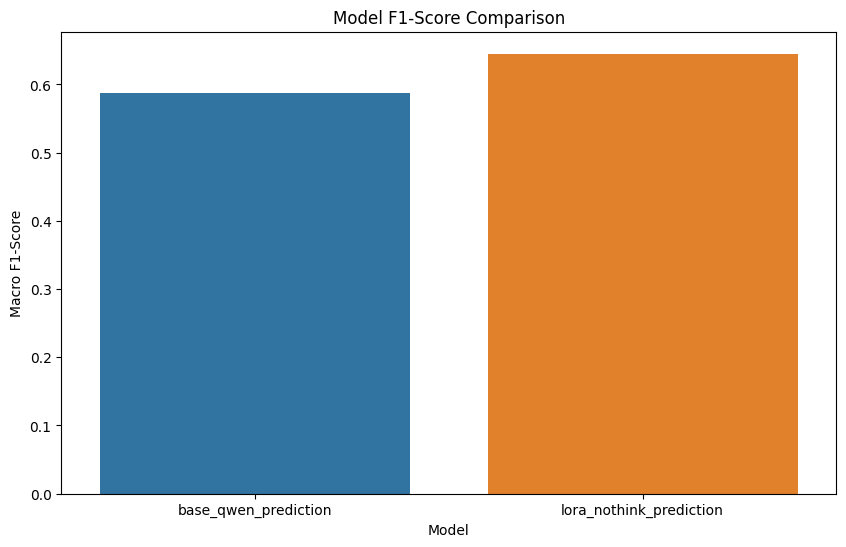

In [8]:
# %%
print("\n" + "="*50)
print("🎯 COMPREHENSIVE BENCHMARK REPORT 🎯")
print("="*50)

metrics_data = []

for model in models:
    res = eval_results[model]
    print(f"\n--- Model: {model} ---")
    print(f"Failed Parses: {res['failed']}")
    
    if res['bias_errors']:
        # mae = np.mean(res['bias_errors'])
        
        macro_f1 = f1_score(res['y_true'], res['y_pred'], labels=IDEOLOGY_CLASSES, average='macro', zero_division=0)
        # acc = accuracy_score(res['y_true'], res['y_pred'])
        
        # print(f"📉 Bias MAE: {mae:.4f}")
        print(f"📊 Class F1 (Macro): {macro_f1:.4f}")
        
        # metrics_data.append({"Model": model, "Metric": "MAE", "Score": mae})
        metrics_data.append({"Model": model, "Metric": "F1-Score", "Score": macro_f1})
        # metrics_data.append({"Model": model, "Metric": "Accuracy", "Score": acc})
        
    # if res['reasoning_sim']:
    #     r_sim = np.mean(res['reasoning_sim'])
    #     print(f"🧠 Reasoning Sim:  {r_sim:.4f}")
    #     metrics_data.append({"Model": model, "Metric": "Reasoning Sim", "Score": r_sim})

    # if res['jaccard_scores']:
    #     j_score = np.mean(res['jaccard_scores'])
    #     print(f"👥 Entity Jaccard: {j_score:.4f}")
    #     metrics_data.append({"Model": model, "Metric": "Entity Jaccard", "Score": j_score})

# --- VISUALIZATIONS ---
df_metrics = pd.DataFrame(metrics_data)

# 1. Bar Chart for overall metrics
plt.figure(figsize=(10, 6))
# Swapped x to 'Model' since we only have one metric now
sns.barplot(data=df_metrics, x='Model', y='Score', hue='Model') 
plt.title("Model F1-Score Comparison")
plt.ylabel("Macro F1-Score")
plt.show()

# 2. Confusion Matrices for classification (Commented out)
# fig, axes = plt.subplots(1, len(models), figsize=(20, 5))
# for i, model in enumerate(models):
#     res = eval_results[model]
#     if res['y_true'] and res['y_pred']:
#         cm = confusion_matrix(res['y_true'], res['y_pred'], labels=IDEOLOGY_CLASSES)
#         sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
#                     xticklabels=IDEOLOGY_CLASSES, yticklabels=IDEOLOGY_CLASSES, cbar=False)
#         axes[i].set_title(f"{model}")
#         axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
# plt.tight_layout()
# plt.show()